In [2]:
import pandas as pd
import os
from utils import get_df_metrics, get_heatmap, load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [22]:
output_dir = './results_facts/'


In [29]:
def map_importance_scores(importance_score):
    importance_score = int(importance_score)
    if importance_score == 2:  # Key case
        return 1
    elif importance_score == 3:  # Medium importance
        return 2
    elif importance_score == 4:  # Low importance
        return 3
    else:
        raise ValueError("Invalid importance score: expected 1, 2, 3, or 4.")

def get_df(output_dir = './results_facts_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        result_data = load_json(os.path.join(output_dir, result))
        data.append(
            {
                'importance_level': int(result_data['importance']),
                "classification": int(result_data["result"]["classification"]),
                "ground_truth": map_importance_scores(result_data["importance"]),
            }
        )

    df = pd.DataFrame(data)
    return df
def get_heatmap(df: pd.DataFrame, target_col: str, pred_col: str):
    """Plot and display a heatmap of the confusion matrix."""
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(df[target_col], df[pred_col], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

def get_metrics(df):

    # Ground truth and model predictions
    y_true = df['ground_truth']
    y_pred = df['classification']

    # Calculate metrics for multiclass classification
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro")
    recall_macro = recall_score(y_true, y_pred, average="macro")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    precision_micro = precision_score(y_true, y_pred, average="micro")
    recall_micro = recall_score(y_true, y_pred, average="micro")
    f1_micro = f1_score(y_true, y_pred, average="micro")

    # Classification report for additional insights
    report = classification_report(y_true, y_pred, target_names=["High Importance", "Medium Importance", "Low Importance"])

    # Extracting metrics
    metrics = {
        "Accuracy": accuracy,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro,
        "F1 Score (Macro)": f1_macro,
        "Precision (Micro)": precision_micro,
        "Recall (Micro)": recall_micro,
        "F1 Score (Micro)": f1_micro,
    }

    return metrics, report


In [30]:
output_dir = './results_facts/'
df = get_df(output_dir)
metrics, report = get_metrics(df)
metrics

{'Accuracy': 0.45066666666666666,
 'Precision (Macro)': 0.47636105073922025,
 'Recall (Macro)': 0.4506666666666667,
 'F1 Score (Macro)': 0.43297772892327496,
 'Precision (Micro)': 0.45066666666666666,
 'Recall (Micro)': 0.45066666666666666,
 'F1 Score (Micro)': 0.45066666666666666}

In [31]:
print(report)

                   precision    recall  f1-score   support

  High Importance       0.55      0.54      0.55       125
Medium Importance       0.38      0.61      0.46       125
   Low Importance       0.50      0.20      0.29       125

         accuracy                           0.45       375
        macro avg       0.48      0.45      0.43       375
     weighted avg       0.48      0.45      0.43       375



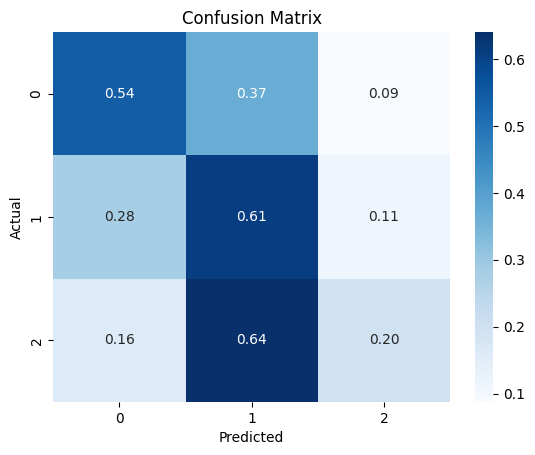

In [32]:
get_heatmap(df, 'ground_truth',  'classification')  

In [33]:
def map_importance_scores(importance_score):
    importance_score = int(importance_score)
    if importance_score == 2:  # Key case
        return 1
    elif importance_score == 3:  # Medium importance
        return 2
    elif importance_score == 4:  # Low importance
        return 3
    else:
        raise ValueError("Invalid importance score: expected 1, 2, 3, or 4.")

def get_df(output_dir = './results_facts_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        result_data = load_json(os.path.join(output_dir, result))
        data.append(
            {
                'importance_level': int(result_data['importance']),
                "classification": int(result_data["result"]["classification"]),
                "ground_truth": map_importance_scores(result_data["importance"]),
            }
        )

    df = pd.DataFrame(data)
    return df

output_dir = './results_facts_law/'

df = get_df(output_dir)

# Ground truth and model predictions
y_true = df['ground_truth']
y_pred = df['classification']

# Calculate metrics for multiclass classification
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_micro = precision_score(y_true, y_pred, average="micro")
recall_micro = recall_score(y_true, y_pred, average="micro")
f1_micro = f1_score(y_true, y_pred, average="micro")

# Classification report for additional insights
report = classification_report(y_true, y_pred, target_names=["Key Case", "Medium Importance", "Low Importance"])

# Extracting metrics
metrics = {
    "Accuracy": accuracy,
    "Precision (Macro)": precision_macro,
    "Recall (Macro)": recall_macro,
    "F1 Score (Macro)": f1_macro,
    "Precision (Micro)": precision_micro,
    "Recall (Micro)": recall_micro,
    "F1 Score (Micro)": f1_micro,
}

metrics

{'Accuracy': 0.4,
 'Precision (Macro)': 0.5000761371451027,
 'Recall (Macro)': 0.4000000000000001,
 'F1 Score (Macro)': 0.31672710035344,
 'Precision (Micro)': 0.4,
 'Recall (Micro)': 0.4,
 'F1 Score (Micro)': 0.4}

In [34]:
print(report)

                   precision    recall  f1-score   support

         Key Case       0.44      0.92      0.60       125
Medium Importance       0.26      0.22      0.24       125
   Low Importance       0.80      0.06      0.12       125

         accuracy                           0.40       375
        macro avg       0.50      0.40      0.32       375
     weighted avg       0.50      0.40      0.32       375



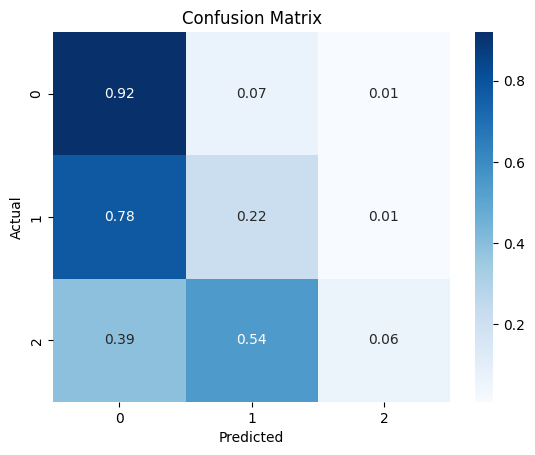

In [35]:
get_heatmap(df, 'ground_truth',  'classification')  